# Supplementary Exercises

```{warning}
This page contains solutions! We recommend attempting each problem before peeking.
```

## 1. Dukes’ C Colorectal Cancer and Diet Treatment

Colorectal cancer is a common cause of death. In the advanced stage of disease, when the disease is first diagnosed in many patients, surgery is the only treatment. Cytotoxic drugs, when given as an adjunct to surgery, do not prevent relapse and do not increase the survival in patients with advanced disease. Interest has been shown, at least by patients, in a nutritional approach to treatment, where diet plays a critical role in the disease management program. In a controlled clinical trial, McIllmurray and Turkie (1987) evaluated the diet treatment in patients with Dukes’ C colorectal cancer. Because the residual tumor mass is small after operation, the relapse rate is high, and no other effective treatment is available. The diet treatment consisted of linolenic acid, an oil extract of the seed from the evening primrose plant *Onagraceae Oenothera biennis* and vitamin E. The data for the treatment and control patients are given below:

$$
\begin{array}{|c|c|c|}
\hline
\text{Group} & \text{Sample Size} & \text{Survival Time (months)} \\
\hline
\text{Treatment (Linoleic acid)} & n_1 = 25 & 
\begin{array}{c}
1+, 5+, 6, 6, 9+, 10, 10, 10+, 12, 12, 12, 12 \\
12+, 13+, 15+, 16+, 20+, 24, 24+, 27+, 32 \\
34+, 36+, 36+, 44+ 
\end{array} \\
\hline
\text{Control} & n_2 = 24 & 
\begin{array}{c}
3+, 6, 6, 6, 6, 8, 8, 12, 12, 12+ \\
15+, 16+, 18+, 18+, 20, 22+, 24, 28+ \\
28+, 28+, 30, 30+, 33+, 42 
\end{array} \\
\hline
\end{array}
$$

This data is available as a csv [here](https://raw.githubusercontent.com/areding/6420-pymc/main/data/dukes.csv).

Fit the data with Weibull distribution, taking the treatment/control (1/0) as a covariate. Place noninformative priors on all parameters. Is the linoleic acid treatment beneficial? Comment.

```{admonition} Solution
:class: tip, dropdown

Code in hidden cell below!
```

In [1]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import pytensor.tensor as pt

data = pd.read_csv("../data/dukes.csv")

censored = data["censored"].to_numpy()
treatment = data["treatment"].to_numpy()
months = data["months"].to_numpy()

with pm.Model():
    alpha = pm.Exponential("alpha", 1)
    beta0 = pm.Normal("beta0", 0, 100)
    beta1 = pm.Normal("beta1", 0, 100)

    beta = pm.math.exp(beta0 + beta1 * treatment) ** (-1 / alpha)

    obs_latent = pm.Weibull.dist(alpha=alpha, beta=beta)
    pm.Censored("lik", obs_latent, lower=None, upper=censored, observed=months)

    # https://docs.pymc.io/en/latest/api/distributions/generated/pymc.Weibull.html
    pm.Deterministic(
        "mean0",
        pt.gamma(1 + 1 / alpha) * (pt.exp(beta0 + beta1 * 0) ** (-1 / alpha)),
    )
    pm.Deterministic(
        "mean1",
        pt.gamma(1 + 1 / alpha) * (pt.exp(beta0 + beta1 * 1) ** (-1 / alpha)),
    )

    pm.Deterministic(
        "median0",
        (np.log(2) * (pt.exp(beta0 + beta1 * 0)) ** (-1 / alpha)),
    )
    pm.Deterministic(
        "median1",
        (np.log(2) * (pt.exp(beta0 + beta1 * 1)) ** (-1 / alpha)),
    )

    trace = pm.sample(3000, target_accept = .9)

az.summary(trace)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta0, beta1]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.370,0.232,0.936,1.801,0.004,0.003,3480.0,4173.0,1.0
beta0,-4.450,0.749,-5.943,-3.153,0.013,0.009,3552.0,3973.0,1.0
beta1,-0.686,0.450,-1.557,0.137,0.006,0.005,5719.0,5149.0,1.0
mean0,24.849,7.131,14.939,37.348,0.089,0.263,7245.0,6449.0,1.0
mean1,41.615,13.881,23.289,65.100,0.175,0.377,7367.0,7045.0,1.0
median0,18.541,4.882,10.894,26.944,0.059,0.159,7516.0,7403.0,1.0
median1,31.003,9.423,17.703,47.228,0.115,0.217,7949.0,7223.0,1.0



## 2. Censored Rayleigh

The lifetime (in hours) of a certain sensor has Rayleigh distribution, with survival function

$$ 
S(t) = \exp\left(-\frac{t^2}{2\lambda}\right), \lambda > 0 
$$

Twelve sensors are placed under test for 100 hours, and the following failure times are recorded: 23, 40, 41, 67, 69, 72, 84, 84, 88, 100+, 100+. Here + denotes a censored time.

1. If failure times $ t_1, \ldots, t_r $ are observed, and $ t_{r+1}, \ldots, t_n $ are censored, find the Bayes estimator of $ \lambda $. Use a noninformative gamma prior on $ \lambda $.
2. Evaluate $ S(t) $ for $ t = 60 $ and find 95% Credible Set.

The MLE for $ \lambda $ is

$$
\hat{\lambda} = \frac{\sum_{i=1}^{r} t_i^2 + \sum_{i=r+1}^{n} t_i^2}{2r}
$$

3. Evaluate the MLE for the given data and comment on closeness to the Bayes estimator in (a).

The Rayleigh distribution is not implemented in PyMC. You can try the zero-trick or create a custom distribution.

```{admonition} Solution
:class: tip, dropdown

A custom distribution is implemented in PyMC using the Rayleigh survival model:

$$f(c,t) = \begin{cases} 
      \frac{t}{\lambda} \exp(\frac{-t^2}{2\lambda}) & \text{if } c = 1 \\
      \exp(\frac{-t^2}{2\lambda}) & \text{if } c = 0 \\
   \end{cases}$$

Censored points are labeled with $c=0$:

```





In [8]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
from pymc.math import log, exp

t = np.array([23, 40, 41, 67, 69, 72, 84, 88, 100, 100])
c = np.array([ 1,  1,  1,  1,  1,  1,  1,  1,   0,   0])

# CustomDist requires all data to be together in a matrix
val = np.concat([[t],[c]])

# log-probability of custom distribution
def logp(value, lam):
    t = value[0,:]
    c = value[1,:]
    return (c * log(t/lam) - ((t**2) / (2*lam))).sum()

with pm.Model() as m:
    λ = pm.Gamma("λ", .001, .001)
    
    rayleigh_surv = pm.CustomDist('rayleigh_surv', λ, logp=logp, observed=val)

    #mean prediction
    S_new = pm.Deterministic("S_new",exp(-(60**2) / (2*λ)))

    trace = pm.sample(5000)

az.summary(trace,hdi_prob=.95)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [λ]
/opt/anaconda3/envs/pymc_env/lib/python3.13/multiprocessing/popen_fork.py:67: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/opt/anaconda3/envs/pymc_env/lib/python3.13/multiprocessing/popen_fork.py:67: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 1 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
S_new,0.492,0.092,0.31,0.669,0.001,0.001,8524.0,13589.0,1.0
λ,2663.574,760.235,1423.04,4205.367,8.133,7.232,8524.0,13589.0,1.0


MLE version of λ: 3315.25


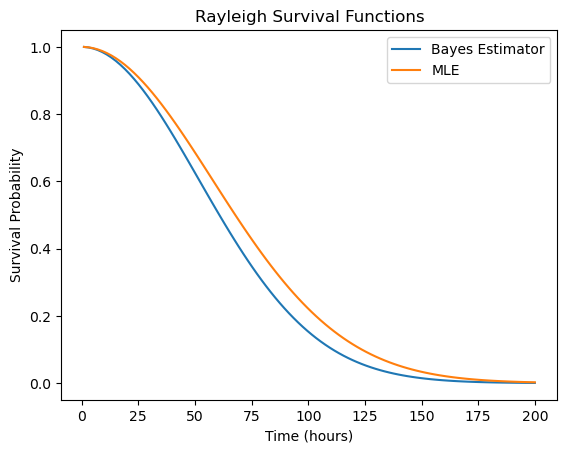

In [9]:
#visualize survival function with mean lambda

import matplotlib.pyplot as plt

# MLE
λ_mle = np.sum(t**2) / (2*sum(c))
print(str("MLE version of λ:") + " " + str(λ_mle))


x = np.linspace(1,200,100)
y1 = np.exp(-(x**2)/(2*az.summary(trace)['mean']['λ']))
y2 = np.exp(-(x**2)/(2*λ_mle))

plt.plot(x,y1,label="Bayes Estimator")
plt.plot(x,y2,label="MLE")
plt.title("Rayleigh Survival Functions")
plt.xlabel("Time (hours)")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

## 3. Stagnant Water with MAR Data

{cite:t}`carlin1992hierarchical` analyzed data on the stagnation of water by piecing together linear parametric forms.

- $ y_i $ is the log flow rate down the channel.
- $ x_i $ is the log height of stagnant surface levels for different surfactants $ i $.

Data is available for download [here](https://raw.githubusercontent.com/areding/6420-pymc/main/data/stagnant_water.csv).

The proposed model is:

\begin{align*}
y_i &\sim N(\mu_i, \sigma^2) \\
\mu_i &= \alpha + \beta_1 \cdot x_i + \beta_2 \cdot (x_i - \theta)_{+}
\end{align*}

Here, $ (a)_{+} $ is $ a $ if $ a \geq 0 $ and 0 if $ a < 0 $.

According to this model, the regression slope is $ \beta_1 $ for $ x < \theta $ and $ \beta_1 + \beta_2 $ for $ x \geq \theta $. The original exercise is modified to have two $ y $'s and two $ x $'s missing at random.

```{admonition} Solution
:class: tip, dropdown

Solution in hidden cell below!

```

In [6]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
from pymc.math import switch, ge

data = pd.read_csv("../data/stagnant_water.csv")

x = data["x"].to_numpy()
y = data["y"].to_numpy()

with pm.Model() as m:

    tau = pm.Gamma("tau", .001, .001)
    alpha = pm.Normal("alpha", 0, sigma = 1000)
    beta1 = pm.Normal("beta1", 0, sigma = 1000)
    beta2 = pm.Normal("beta2", 0, sigma = 1000)
    theta = pm.Uniform("theta",-1.3,1.1)

    x_impute = pm.Uniform("x_impute", -5,5,observed=x)

    mu = alpha + beta1 * x_impute + beta2 * (x_impute-theta) * switch(ge(x_impute - theta, 0), 1, 0)

    likelihood = pm.Normal("likelihood", mu=mu, tau=tau, observed=y)

    trace = pm.sample(5000, nuts_sampler = 'numpyro', target_accept=.8)
    # trace = pm.sample(5000)

az.summary(trace, hdi_prob=.95, var_names=['alpha','beta1','beta2'])

/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pymc/model/core.py:1311: ImputationWarning: Data in x_impute contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pymc/model/core.py:1311: ImputationWarning: Data in likelihood contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.550,0.015,0.521,0.578,0.0,0.0,5980.0,8982.0,1.0
beta1,-0.416,0.016,-0.447,-0.384,0.0,0.0,6393.0,9438.0,1.0
beta2,-0.589,0.022,-0.631,-0.545,0.0,0.0,11754.0,12590.0,1.0
